# Green's Function Analysis

Implements the Green's function approach to Rossi-alpha from:
> Gabrieli, Shokef, Neder (2025), *Efficient calculation of reactor noise via Ito-Langevin Process*

## Physical setup
A fixed-source simulation emits neutrons uniformly throughout the core sphere with U235 Watt fission spectrum.
For each mesh cell $i$, we extract:

- $G_i = \int g_i(t)\,dt$ — total expected detector captures per source neutron from cell $i$ (integrated Green's function)
- $g_i(t)$ — time-resolved detection rate per source neutron from cell $i$
- $F_i = \overline{\nu(\nu-1)} \cdot \tilde{F}_i$ — noise source weight ($\overline{\nu(\nu-1)} \approx 4.63$ for U235)

Then compute the Rossi-alpha (Eq. 55 from paper):
$$R(\tau) = \sum_i F_i \int g_i(t)\, g_i(t+\tau)\, dt$$

**Note on delayed neutrons:** The paper's formula is for prompt neutrons only.
Both prompt-only (`delayed_group == 0`) and all-neutron results are shown.

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import openmc
import scienceplots
from scipy.optimize import curve_fit

from project.core.rossi_mesh import CORE_RADIUS, N_RADIAL, N_THETA, make_fission_mesh

plt.style.use(["science", "notebook", "grid", "high-vis"])

RESULTS_DIR = Path("../../results/greens-function-simulation").resolve()
FIGURES_DIR = Path("../outputs/figures/greens_function")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# U235 nuclear constant (second factorial moment of fission multiplicity)
NU_NU_MINUS_1 = 4.63

mesh = make_fission_mesh()
r_edges = np.asarray(mesh.r_grid)       # shape (N_RADIAL+1,)
theta_edges = np.asarray(mesh.theta_grid)  # shape (N_THETA+1,)
r_mid = 0.5 * (r_edges[:-1] + r_edges[1:])
cos_theta_edges = np.cos(theta_edges)
n_cells = N_RADIAL * N_THETA

print(f"Mesh: {N_RADIAL} radial × {N_THETA} theta = {n_cells:,} equal-volume cells")
print(f"Results dir: {RESULTS_DIR}")

Mesh: 100 radial × 50 theta = 5,000 equal-volume cells
Results dir: /home/itay/projects/initiation-project/project/results/greens-function-simulation


## 1. Load simulation data

In [2]:
# Load source particle mesh mapping
mesh_ids = np.load(RESULTS_DIR / "source_mesh_ids.npy")
n_particles = len(mesh_ids)
print(f"Source particles: {n_particles:,}")
print(f"Particles inside mesh: {np.sum(mesh_ids >= 0):,}")

# Source particles per mesh cell (for normalization of g_i)
src_per_cell = np.bincount(mesh_ids[mesh_ids >= 0], minlength=n_cells).astype(float)
src_per_cell = np.where(src_per_cell > 0, src_per_cell, np.nan)  # avoid division by zero

# Load fission tally: fissions per source particle per cell
sp = openmc.StatePoint(str(RESULTS_DIR / "statepoint.1.h5"))
tally = sp.get_tally(name="fission_per_cell")
F_tally = tally.mean.flatten()  # shape (n_cells,)

# F_i = ν(ν-1) × fission_tally_i  (Eq. 8 from paper)
F = NU_NU_MINUS_1 * F_tally

print(f"Total fissions / source neutron: {F_tally.sum():.4e}")
print(f"Total F_i = ν(ν-1) × Σ F_tally: {F.sum():.4e}")

# Load collision track
with h5py.File(RESULTS_DIR / "collision_track.h5", "r") as f:
    track = f["collision_track_bank"][()]

det_times = track["time"]
det_parent_ids = track["parent_id"]
det_delayed_group = track["delayed_group"]

# Map each detection to its source mesh cell
det_cell_ids = mesh_ids[det_parent_ids - 1]  # parent_id is 1-based

# Prompt-only mask
prompt_mask = det_delayed_group == 0

print(f"\nTotal detection events: {len(det_times):,}")
print(f"  Prompt (delayed_group=0): {prompt_mask.sum():,} ({100*prompt_mask.mean():.1f}%)")
print(f"  Delayed (delayed_group>0): {(~prompt_mask).sum():,} ({100*(~prompt_mask).mean():.1f}%)")
print(f"  Time range: {det_times.min():.3e} – {det_times.max():.3e} s")

Source particles: 1,000,000
Particles inside mesh: 1,000,000
Total fissions / source neutron: 1.5154e+01
Total F_i = ν(ν-1) × Σ F_tally: 7.0161e+01

Total detection events: 155,307
  Prompt (delayed_group=0): 154,662 (99.6%)
  Delayed (delayed_group>0): 645 (0.4%)
  Time range: 2.704e-09 – 5.726e+02 s


## 2. Integrated Green's function $G_i = \int g_i(t)\,dt$

$G_i$ is the expected total number of detector captures per source neutron from mesh cell $i$,
including all fission-chain descendants. It is the spatial Green's function of the sphere to the detector.

We compute it for **prompt neutrons only** (matching the paper's assumption).

In [3]:
# Count prompt detections per source cell
prompt_cell_ids = det_cell_ids[prompt_mask]
det_per_cell_prompt = np.bincount(prompt_cell_ids[prompt_cell_ids >= 0], minlength=n_cells).astype(float)

# Also for all neutrons (for comparison)
all_cell_ids = det_cell_ids
det_per_cell_all = np.bincount(all_cell_ids[all_cell_ids >= 0], minlength=n_cells).astype(float)

# Normalize by source particles per cell → G_i = detections / source
G_prompt = det_per_cell_prompt / src_per_cell  # shape (n_cells,)
G_all    = det_per_cell_all    / src_per_cell

print(f"G_i (prompt) stats:  mean={np.nanmean(G_prompt):.4e}, max={np.nanmax(G_prompt):.4e}")
print(f"G_i (all)    stats:  mean={np.nanmean(G_all):.4e}, max={np.nanmax(G_all):.4e}")
print(f"Delayed fraction of total detections: {1 - np.nansum(G_prompt)/np.nansum(G_all):.1%}")

G_i (prompt) stats:  mean=1.5449e-01, max=1.5312e+00
G_i (all)    stats:  mean=1.5513e-01, max=1.5312e+00
Delayed fraction of total detections: 0.4%


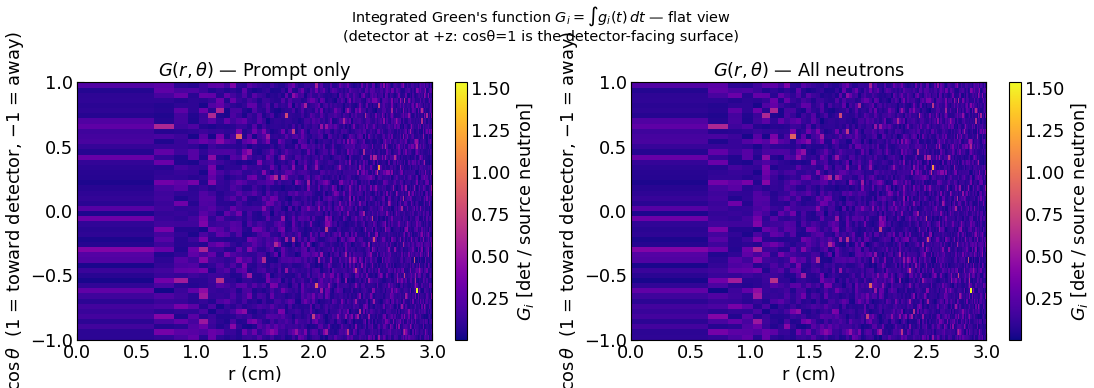

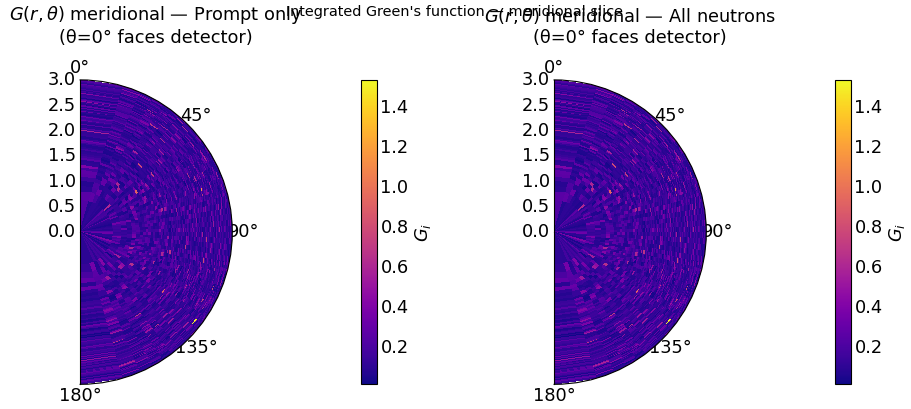

In [4]:
from matplotlib.gridspec import GridSpec

# Reshape to 2D: [i_theta, i_r] (r varies fastest in OpenMC flat index)
G_prompt_2d = G_prompt.reshape(N_THETA, N_RADIAL)
G_all_2d    = G_all.reshape(N_THETA, N_RADIAL)

# --- Flat (r, cos θ) heatmaps — prompt vs all ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=80)
for ax, G_2d_data, label in zip(axes,
                                 [G_prompt_2d, G_all_2d],
                                 ["Prompt only", "All neutrons"]):
    im = ax.pcolormesh(r_edges, cos_theta_edges, G_2d_data, cmap="plasma", shading="flat")
    plt.colorbar(im, ax=ax, label="$G_i$ [det / source neutron]")
    ax.set_xlabel("r (cm)")
    ax.set_ylabel(r"$\cos\theta$  (1 = toward detector, −1 = away)")
    ax.set_title(f"$G(r,\\theta)$ — {label}")
plt.suptitle(r"Integrated Green's function $G_i = \int g_i(t)\,dt$ — flat view"
             "\n(detector at +z: cosθ=1 is the detector-facing surface)",
             fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "greens_function_flat.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Polar meridional slices ---
fig = plt.figure(figsize=(12, 5), dpi=80)
gs = GridSpec(1, 2, fig)
for col, (G_2d_data, label) in enumerate([(G_prompt_2d, "Prompt only"),
                                           (G_all_2d,    "All neutrons")]):
    ax = fig.add_subplot(gs[0, col], projection="polar")
    im = ax.pcolormesh(theta_edges, r_edges, G_2d_data.T, cmap="plasma", shading="flat")
    plt.colorbar(im, ax=ax, label="$G_i$", pad=0.12)
    ax.set_theta_zero_location("N")   # θ=0 (detector direction) at top
    ax.set_theta_direction(-1)
    ax.set_thetamin(0)
    ax.set_thetamax(180)
    ax.set_title(f"$G(r,\\theta)$ meridional — {label}\n(θ=0° faces detector)", pad=15)
plt.suptitle(r"Integrated Green's function — meridional slice", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "greens_function_polar.png", dpi=300, bbox_inches="tight")
plt.show()

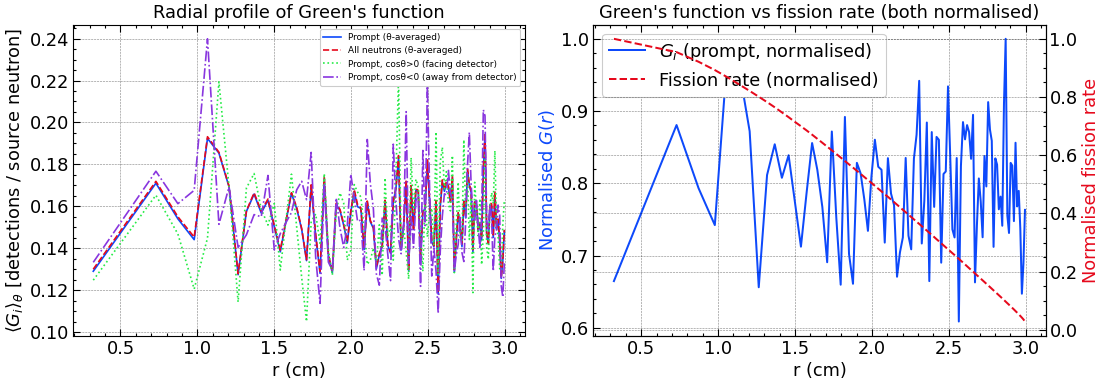

G_i (θ-avg) peaks at r = 2.87 cm
G_i facing detector peaks at r = 2.31 cm
Fission rate peaks at r = 0.32 cm
Mean G facing / mean G away = 0.996


In [5]:
# Radial profile: marginalise over theta, compare to fission rate
G_radial_prompt = np.nanmean(G_prompt_2d, axis=0)  # mean over theta bins
G_radial_all    = np.nanmean(G_all_2d,    axis=0)
F_tally_radial  = F_tally.reshape(N_THETA, N_RADIAL).mean(axis=0)

# Directional split: facing detector (cosθ > 0) vs facing away (cosθ < 0)
n_half = N_THETA // 2
G_facing  = np.nanmean(G_prompt_2d[:n_half, :], axis=0)   # cosθ > 0 (toward detector)
G_away    = np.nanmean(G_prompt_2d[n_half:, :], axis=0)   # cosθ < 0 (away from detector)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=80)

ax = axes[0]
ax.plot(r_mid, G_radial_prompt, lw=1.5, label="Prompt (θ-averaged)")
ax.plot(r_mid, G_radial_all,    lw=1.5, ls="--", label="All neutrons (θ-averaged)")
ax.plot(r_mid, G_facing,        lw=1.5, ls=":",  label="Prompt, cosθ>0 (facing detector)")
ax.plot(r_mid, G_away,          lw=1.5, ls="-.", label="Prompt, cosθ<0 (away from detector)")
ax.set_xlabel("r (cm)")
ax.set_ylabel(r"$\langle G_i \rangle_\theta$ [detections / source neutron]")
ax.set_title("Radial profile of Green's function")
ax.legend(fontsize=8)

ax = axes[1]
ax2 = ax.twinx()
l1, = ax.plot(r_mid, G_radial_prompt / np.nanmax(G_radial_prompt), lw=1.8,
              color="C0", label="$G_i$ (prompt, normalised)")
l2, = ax2.plot(r_mid, F_tally_radial / F_tally_radial.max(), lw=1.8, ls="--",
               color="C1", label="Fission rate (normalised)")
ax.set_xlabel("r (cm)")
ax.set_ylabel("Normalised $G(r)$", color="C0")
ax2.set_ylabel("Normalised fission rate", color="C1")
ax.set_title("Green's function vs fission rate (both normalised)")
ax.legend(handles=[l1, l2])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "greens_function_radial.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"G_i (θ-avg) peaks at r = {r_mid[np.nanargmax(G_radial_prompt)]:.2f} cm")
print(f"G_i facing detector peaks at r = {r_mid[np.nanargmax(G_facing)]:.2f} cm")
print(f"Fission rate peaks at r = {r_mid[np.argmax(F_tally_radial)]:.2f} cm")
print(f"Mean G facing / mean G away = {np.nanmean(G_facing)/np.nanmean(G_away):.3f}")

## 3. Time-resolved Green's function $g_i(t)$

The time-resolved Green's function $g_i(t)$ shows how detections from cell $i$ are
distributed in time. Cells near the detector (small transport time) show an earlier,
sharper peak; cells far away show a broader, delayed pulse due to multiple scatterings
and longer diffusion paths.

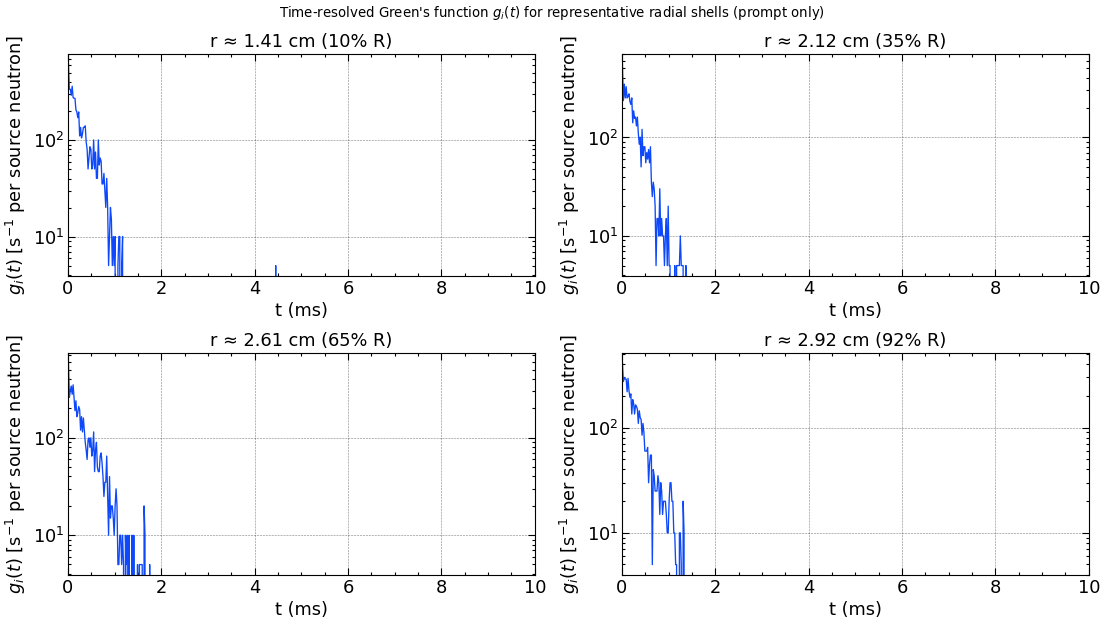

In [6]:
# Time histogram settings
T_MAX = 1e-2   # 10 ms: covers the prompt neutron transient
N_T = 500      # time bins for g_i(t) display
time_bins = np.linspace(0, T_MAX, N_T + 1)
t_mid = 0.5 * (time_bins[:-1] + time_bins[1:])
dt_display = T_MAX / N_T

# Select representative radial shells (averaged over all theta bins)
# We pick 4 radii: inner, inner-mid, outer-mid, near-surface
shell_fracs = [0.1, 0.35, 0.65, 0.92]  # r/R fractions
shell_r_indices = [int(f * N_RADIAL) for f in shell_fracs]
shell_labels = [f"r ≈ {r_mid[i]:.2f} cm ({f:.0%} R)" for i, f in zip(shell_r_indices, shell_fracs)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=80, sharey=False)

for ax, i_r, label in zip(axes.flat, shell_r_indices, shell_labels):
    # Collect all theta cells at this radial index
    # Flat index: cell_flat = i_theta * N_RADIAL + i_r
    shell_cell_flat = [i_theta * N_RADIAL + i_r for i_theta in range(N_THETA)]

    # Prompt detections from these cells
    shell_mask = np.isin(det_cell_ids, shell_cell_flat) & prompt_mask
    times_shell = det_times[shell_mask]
    n_src_shell = src_per_cell[shell_cell_flat].sum()  # total source particles in this shell

    g_i, _ = np.histogram(times_shell, bins=time_bins)
    g_i_norm = g_i.astype(float) / (n_src_shell * dt_display)  # per source per second

    ax.plot(t_mid * 1e3, g_i_norm, lw=1.2, color="C0")
    ax.set_xlabel("t (ms)")
    ax.set_ylabel(r"$g_i(t)$ [s$^{-1}$ per source neutron]")
    ax.set_title(label)
    ax.set_yscale("log")
    ax.set_xlim(0, T_MAX * 1e3)

plt.suptitle(r"Time-resolved Green's function $g_i(t)$ for representative radial shells (prompt only)",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "greens_function_time.png", dpi=300, bbox_inches="tight")
plt.show()

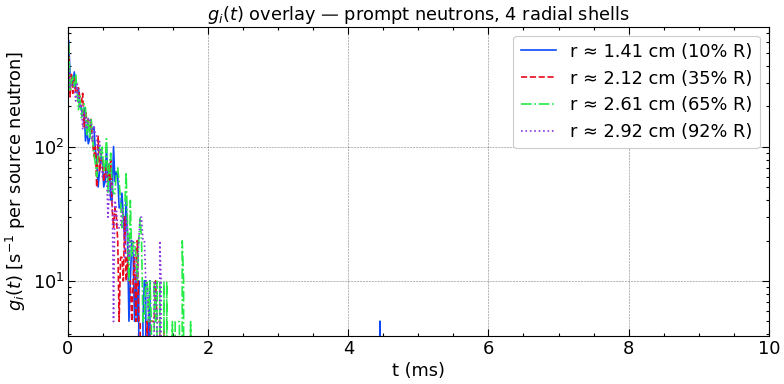

In [7]:
# Overlay all 4 shells on one plot
fig, ax = plt.subplots(figsize=(10, 5), dpi=80)

for i_r, label, color in zip(shell_r_indices, shell_labels, ["C0", "C1", "C2", "C3"]):
    shell_cell_flat = [i_theta * N_RADIAL + i_r for i_theta in range(N_THETA)]
    shell_mask = np.isin(det_cell_ids, shell_cell_flat) & prompt_mask
    times_shell = det_times[shell_mask]
    n_src_shell = src_per_cell[shell_cell_flat].sum()
    g_i, _ = np.histogram(times_shell, bins=time_bins)
    g_i_norm = g_i.astype(float) / (n_src_shell * dt_display)
    ax.plot(t_mid * 1e3, g_i_norm, lw=1.5, color=color, label=label)

ax.set_xlabel("t (ms)")
ax.set_ylabel(r"$g_i(t)$ [s$^{-1}$ per source neutron]")
ax.set_title(r"$g_i(t)$ overlay — prompt neutrons, 4 radial shells")
ax.set_yscale("log")
ax.set_xlim(0, T_MAX * 1e3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "greens_function_time_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Rossi-alpha $R(\tau) = \sum_i F_i \int g_i(t)\, g_i(t+\tau)\, dt$

Following Eq. (55) of the paper. Computed for both prompt-only and all-neutron cases.

In [8]:
from scipy.signal import correlate as sp_correlate

TAU_MAX = 1e-2   # 10 ms — maximum lag
N_TAU   = 256    # number of τ bins
T_FULL  = 1.0    # 1 s — time range for g_i(t) histograms

dt = TAU_MAX / N_TAU
time_bins_rossi = np.arange(0, T_FULL + dt, dt)
n_t_bins = len(time_bins_rossi) - 1
tau_centers = np.linspace(dt / 2, TAU_MAX - dt / 2, N_TAU)

print(f"dt = {dt*1e6:.1f} μs,  n_t_bins = {n_t_bins:,},  τ range = [0, {TAU_MAX*1e3:.0f}] ms")

def compute_rossi(mask_events, label):
    """Compute R(τ) = Σ_i F_i ∫ g_i(t) g_i(t+τ) dt.

    Uses FFT-based autocorrelation (scipy.signal.correlate method='fft'),
    which is O(n log n) per cell vs O(n²) for direct computation.
    Lag=0 is skipped (unphysical self-pairs); lags 1..N_TAU are used.
    """
    masked_cell_ids = det_cell_ids[mask_events]
    masked_times    = det_times[mask_events]

    # Group detection times by source cell
    cell_event_times = {}
    for cell_id, t in zip(masked_cell_ids, masked_times):
        if cell_id >= 0:
            cell_event_times.setdefault(cell_id, []).append(t)

    R_tau = np.zeros(N_TAU)
    cells_used = 0

    for cell_i, times_i in cell_event_times.items():
        if len(times_i) < 2:
            continue
        g_i, _ = np.histogram(times_i, bins=time_bins_rossi)
        g_i = g_i.astype(np.float64)
        F_i = F[cell_i]  # already includes ν(ν-1)

        # FFT-based autocorrelation — O(n log n) instead of O(n²)
        # corr[n_t_bins + k - 1] = Σ_j g_i[j] * g_i[j+k]  for lag k
        corr = sp_correlate(g_i, g_i, mode="full", method="fft")
        # lags 1..N_TAU correspond to indices n_t_bins..n_t_bins+N_TAU-1
        R_tau += F_i * corr[n_t_bins: n_t_bins + N_TAU] * dt
        cells_used += 1

    print(f"[{label}] Cells with ≥2 detections: {cells_used:,} / {n_cells:,}")
    print(f"[{label}] R(τ) range: [{R_tau.min():.4e}, {R_tau.max():.4e}]")
    return R_tau

# Compute for prompt-only and all neutrons
R_prompt = compute_rossi(prompt_mask, "Prompt only")
R_all    = compute_rossi(np.ones(len(det_times), dtype=bool), "All neutrons")

dt = 39.1 μs,  n_t_bins = 25,600,  τ range = [0, 10] ms
[Prompt only] Cells with ≥2 detections: 4,999 / 5,000
[Prompt only] R(τ) range: [-1.0040e-18, 1.1532e-01]
[All neutrons] Cells with ≥2 detections: 4,999 / 5,000
[All neutrons] R(τ) range: [-1.0029e-18, 1.1532e-01]


In [9]:
def rossi_model(tau, A, B, alpha):
    return A + B * np.exp(alpha * tau)

results = {}
for name, R_tau in [("Prompt only", R_prompt), ("All neutrons", R_all)]:
    p0 = [R_tau[-1], R_tau[0] - R_tau[-1], -500.0]
    try:
        popt, pcov = curve_fit(rossi_model, tau_centers, R_tau, p0=p0, maxfev=20000)
        perr = np.sqrt(np.diag(pcov))
        results[name] = (popt, perr)
        A_fit, B_fit, alpha_fit = popt
        print(f"[{name}] α = {alpha_fit:.1f} ± {perr[2]:.1f} s⁻¹  "
              f"(decay time = {-1/alpha_fit*1e3:.3f} ms)")
    except Exception as e:
        print(f"[{name}] Fit failed: {e}")
        results[name] = None

[Prompt only] α = -3594.0 ± 4.9 s⁻¹  (decay time = 0.278 ms)
[All neutrons] α = -3594.1 ± 4.9 s⁻¹  (decay time = 0.278 ms)


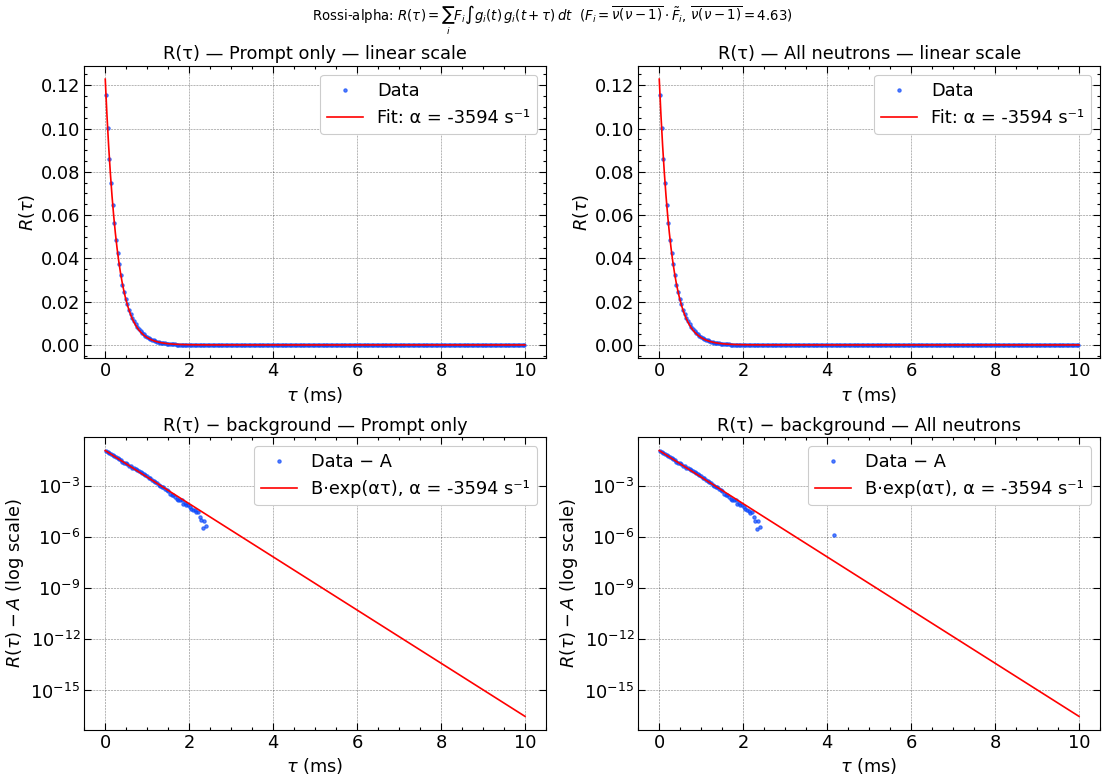

In [10]:
tau_fine = np.linspace(0, TAU_MAX, 1000)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=80)

for col, (name, R_tau) in enumerate([("Prompt only", R_prompt), ("All neutrons", R_all)]):
    fit = results.get(name)
    popt = fit[0] if fit else None

    # Linear scale
    ax = axes[0, col]
    ax.plot(tau_centers * 1e3, R_tau, "o", ms=3, alpha=0.7, label="Data")
    if popt is not None:
        A_fit, B_fit, alpha_fit = popt
        ax.plot(tau_fine * 1e3, rossi_model(tau_fine, *popt), "r-", lw=1.5,
                label=f"Fit: α = {alpha_fit:.0f} s⁻¹")
    ax.set_xlabel(r"$\tau$ (ms)")
    ax.set_ylabel(r"$R(\tau)$")
    ax.set_title(f"R(τ) — {name} — linear scale")
    ax.legend()

    # Semi-log scale (subtract background A)
    ax = axes[1, col]
    if popt is not None:
        A_fit, B_fit, alpha_fit = popt
        R_corr = R_tau - A_fit
        R_pos = np.where(R_corr > 0, R_corr, np.nan)
        ax.semilogy(tau_centers * 1e3, R_pos, "o", ms=3, alpha=0.7, label="Data − A")
        ax.semilogy(tau_fine * 1e3, rossi_model(tau_fine, 0, B_fit, alpha_fit),
                    "r-", lw=1.5, label=f"B·exp(ατ), α = {alpha_fit:.0f} s⁻¹")
    ax.set_xlabel(r"$\tau$ (ms)")
    ax.set_ylabel(r"$R(\tau) - A$ (log scale)")
    ax.set_title(f"R(τ) − background — {name}")
    ax.legend()

plt.suptitle(
    r"Rossi-alpha: $R(\tau) = \sum_i F_i \int g_i(t)\, g_i(t+\tau)\, dt$  "
    r"($F_i = \overline{\nu(\nu-1)} \cdot \tilde{F}_i$, $\overline{\nu(\nu-1)} = 4.63$)",
    fontsize=12
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rossi_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary

| Quantity | Value |
|---|---|
| Prompt decay constant α (prompt only) | from fit above |
| Prompt decay constant α (all neutrons) | from fit above |
| ν(ν−1) used | 4.63 (U235 ENDF) |
| Source | Uniform sphere, U235 Watt spectrum |
| Delayed neutron fraction | ~0.4% of detections (negligible for this geometry) |

In [11]:
print("=" * 50)
print("GREEN'S FUNCTION ANALYSIS SUMMARY")
print("=" * 50)
print(f"Total source particles:          {n_particles:,}")
print(f"Total detection events:          {len(det_times):,}")
print(f"  Prompt:                        {prompt_mask.sum():,} ({100*prompt_mask.mean():.1f}%)")
print(f"  Delayed:                       {(~prompt_mask).sum():,} ({100*(~prompt_mask).mean():.1f}%)")
print(f"Mean G_i (prompt):               {np.nanmean(G_prompt):.4e} det/source")
print(f"Total fissions/source neutron:   {F_tally.sum():.4e}")
for name, fit in results.items():
    if fit:
        popt, perr = fit
        print(f"α [{name}]:  {popt[2]:.1f} ± {perr[2]:.1f} s⁻¹  "
              f"(τ_prompt = {-1/popt[2]*1e3:.3f} ms)")

GREEN'S FUNCTION ANALYSIS SUMMARY
Total source particles:          1,000,000
Total detection events:          155,307
  Prompt:                        154,662 (99.6%)
  Delayed:                       645 (0.4%)
Mean G_i (prompt):               1.5449e-01 det/source
Total fissions/source neutron:   1.5154e+01
α [Prompt only]:  -3594.0 ± 4.9 s⁻¹  (τ_prompt = 0.278 ms)
α [All neutrons]:  -3594.1 ± 4.9 s⁻¹  (τ_prompt = 0.278 ms)
